In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("cardekho.csv")

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='str')

In [5]:
df = df.drop("Unnamed: 0" , axis = 1)

In [6]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.5 MB


In [8]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [9]:
df["seats"].value_counts()

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64

In [10]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [11]:
df = df[df["seats"] > 0]

In [12]:
df["seats"].value_counts()

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
Name: count, dtype: int64

In [13]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
197,Honda City,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
360,Maruti Baleno,Maruti,Baleno,2,5000,Individual,Petrol,Automatic,21.40,1197,83.10,5,686000
1353,Maruti Swift Dzire,Maruti,Swift Dzire,4,50000,Individual,Diesel,Manual,28.40,1248,74.02,5,680000
1429,Maruti Wagon R,Maruti,Wagon R,13,100000,Individual,Petrol,Manual,18.90,1061,67.00,5,150000
1485,Hyundai i20,Hyundai,i20,3,50000,Individual,Petrol,Manual,18.60,1197,81.83,5,625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti Swift,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti Wagon R,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata Tiago,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai Grand,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


In [14]:
df.shape

(15409, 13)

In [15]:
df = df.drop_duplicates(keep="first",ignore_index=True)

In [16]:
df.shape

(15242, 13)

In [17]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15242.000000,1.524200e+04,15242.000000,15242.000000,15242.000000,15242.000000,1.524200e+04
mean,6.040611,5.564360e+04,19.697792,1486.172746,100.607175,5.326860,7.747198e+05
std,3.014693,5.176822e+04,4.169227,520.453492,42.918455,0.806508,8.947135e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


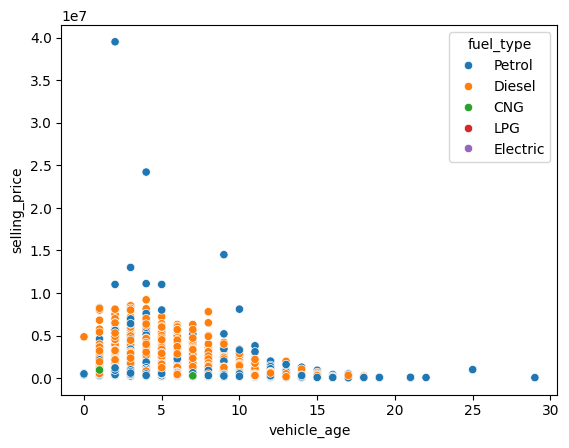

In [18]:
sns.scatterplot(x=df["vehicle_age"] , y=df["selling_price"] , hue= df["fuel_type"])
plt.show()

In [19]:
df = df[df["selling_price"] < 2300000]

In [20]:
df.shape

(14587, 13)

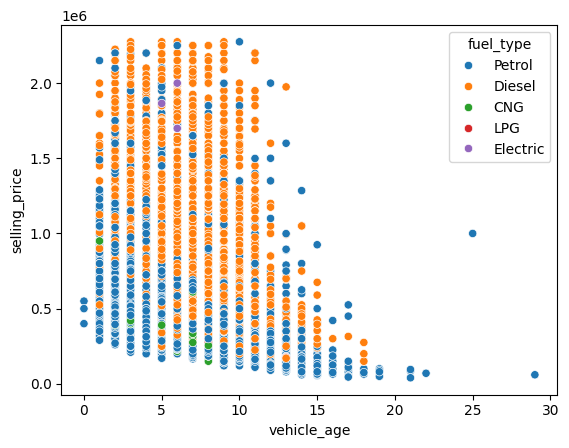

In [21]:
sns.scatterplot(x=df["vehicle_age"] , y=df["selling_price"] , hue= df["fuel_type"])
plt.show()

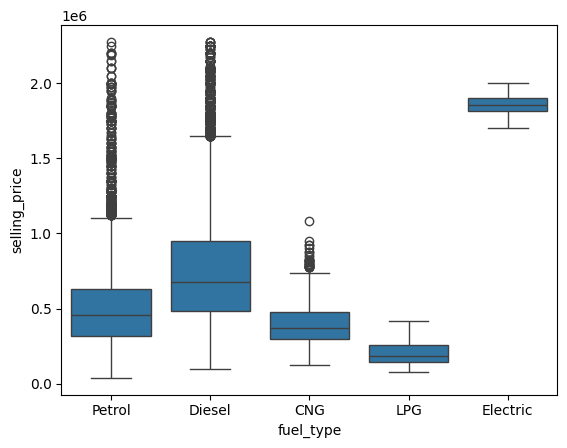

In [22]:
sns.boxplot(data=df,x="fuel_type",y="selling_price")
plt.show()

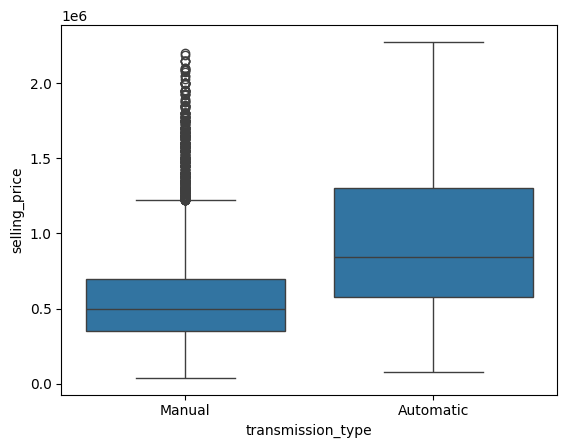

In [23]:
sns.boxplot(data=df,x="transmission_type",y="selling_price")
plt.show()

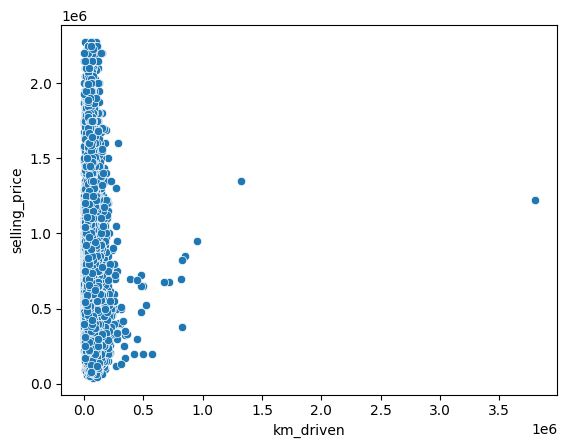

In [24]:
sns.scatterplot(x=df["km_driven"],y=df["selling_price"])
plt.show()

In [25]:
df["km_driven"].max()

np.int64(3800000)

In [26]:
df = df[df["km_driven"] < 1000000]

In [27]:
df.shape

(14585, 13)

In [28]:
df.corr(numeric_only=True)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.000000,0.421759,-0.289816,0.153519,0.069246,0.043723,-0.361530
km_driven,0.421759,1.000000,-0.143911,0.299151,0.120247,0.236160,-0.066821
mileage,-0.289816,-0.143911,1.000000,-0.615592,-0.524700,-0.451963,-0.319179
engine,0.153519,0.299151,-0.615592,1.000000,0.765451,0.626103,0.617809
max_power,0.069246,0.120247,-0.524700,0.765451,1.000000,0.229633,0.731893
seats,0.043723,0.236160,-0.451963,0.626103,0.229633,1.000000,0.285974
selling_price,-0.361530,-0.066821,-0.319179,0.617809,0.731893,0.285974,1.000000


In [29]:
X = df.drop("selling_price" , axis = 1)
y = df["selling_price"]

In [30]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 14585 entries, 0 to 15241
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           14585 non-null  str    
 1   brand              14585 non-null  str    
 2   model              14585 non-null  str    
 3   vehicle_age        14585 non-null  int64  
 4   km_driven          14585 non-null  int64  
 5   seller_type        14585 non-null  str    
 6   fuel_type          14585 non-null  str    
 7   transmission_type  14585 non-null  str    
 8   mileage            14585 non-null  float64
 9   engine             14585 non-null  int64  
 10  max_power          14585 non-null  float64
 11  seats              14585 non-null  int64  
 12  selling_price      14585 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.6 MB


In [32]:
categoric = [col for col in df.columns if df[col].dtype == "str"]

In [33]:
categoric

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [34]:
df[categoric].nunique()

car_name             99
brand                26
model                99
seller_type           3
fuel_type             5
transmission_type     2
dtype: int64

In [35]:
onehot_columns = ["seller_type" , "fuel_type" , "transmission_type"]
freq_columns = ["brand" , "model" , "car_name"]

In [36]:
for col in freq_columns:
    freq = X_train[col].value_counts(normalize= True)

    X_train[col] = X_train[col].map(freq)
    X_test[col] = X_test[col].map(freq)
for col in freq_columns:
    X_test[col] = X_test[col].fillna(0)

In [37]:
from sklearn.preprocessing import OneHotEncoder

In [38]:
onehot = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

In [39]:
X_train_enc = onehot.fit_transform(X_train[onehot_columns])
X_test_enc = onehot.transform(X_test[onehot_columns])

In [40]:
X_train_final = pd.concat([X_train.drop(columns=onehot_columns) , pd.DataFrame(X_train_enc , index=X_train.index).add_prefix("enc")] , axis= 1)
X_test_final = pd.concat([X_test.drop(columns=onehot_columns) , pd.DataFrame(X_test_enc , index= X_test.index).add_prefix("enc")] , axis=1)

In [41]:
X_train_final.head()

,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,enc0,enc1,enc2,enc3,enc4,enc5,enc6,enc7,enc8,enc9
5719,0.055022,0.339218,0.055022,4,50000,28.40,1248,74.00,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1632,0.011656,0.100189,0.011656,4,15000,18.70,1199,88.70,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
9499,0.007371,0.014484,0.007371,6,49000,18.88,1995,184.00,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
13650,0.041052,0.203291,0.041052,7,70000,18.90,1197,82.00,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2635,0.053137,0.339218,0.053137,3,5917,23.95,998,67.05,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [42]:
X_test_final.head()

,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,enc0,enc1,enc2,enc3,enc4,enc5,enc6,enc7,enc8,enc9
12026,0.024854,0.051166,0.024854,8,64000,22.70,1498,89.84,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8456,0.034453,0.203291,0.034453,8,104500,22.32,1582,126.30,5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2230,0.022026,0.068306,0.022026,8,60000,15.10,2179,140.00,7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8832,0.022026,0.068306,0.022026,6,40000,15.10,2179,140.00,7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
764,0.053137,0.339218,0.053137,5,25000,23.95,998,67.05,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [43]:
from sklearn.ensemble import AdaBoostRegressor

In [80]:
model = AdaBoostRegressor(n_estimators=150)

In [81]:
model.fit(X_train_final,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",150
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [82]:
y_pred = model.predict(X_test_final)

In [83]:
r2_score(y_test,y_pred)

0.7767565327088336